# sCITEconcept

## Training method and benchmark results

sCITEconcept is a 1024-dimensional single-cell RNA encoder obtained by
fine-tuning scConcept with paired RNA and surface-protein measurements from
CITE-seq studies.

This notebook is both the method description and the result report. It explains
how the model was trained, defines every reported score, shows the comparison
with the unchanged base scConcept model, and keeps limitations beside the
results they qualify.

Main conclusions:

- sCITEconcept transfers cell state more effectively across datasets and
  measurement platforms.
- It improves retrieval of the same tissue region across independently measured
  spatial assays.
- Its overall frozen-embedding score is only modestly higher than base
  scConcept and does not meet the benchmark's prespecified winner margin.
- Base scConcept is more invariant to large changes in the measured gene panel.
- The downstream cell-communication gain is concentrated in coexpressive
  relationships; inhibitory performance is statistically indistinguishable.

All displayed outputs are committed. Re-executing this notebook uses only the
small tables in `data/`; it does not require source cell matrices, model
weights, or a GPU.


## Contents

1. [Model identity and inference contract](#1-model-identity-and-inference-contract)
2. [Training method](#2-training-method)
3. [Evaluation principles](#3-evaluation-principles)
4. [Frozen-embedding benchmark](#4-frozen-embedding-benchmark)
5. [Broader biological benchmark suite](#5-broader-biological-benchmark-suite)
6. [Independent spatial-platform benchmark](#6-independent-spatial-platform-benchmark)
7. [Cell-communication direction benchmark](#7-cell-communication-direction-benchmark)
8. [Transformer-layer analysis](#8-transformer-layer-analysis)
9. [Recommendations and limitations](#9-recommendations-and-limitations)
10. [Reproduction](#10-reproduction)


## 1. Model identity and inference contract

The base model is `theislab/scConcept`, variant
`corpus230M[human]-model170M`, pinned to revision
`10ed3ec8f35249247c33e1835e381a4c935ee26f`. The selected sCITEconcept
checkpoint is epoch 94.

**Model weights:**
[`alunalabs/sCITEconcept`](https://huggingface.co/alunalabs/sCITEconcept)

At inference time, RNA counts pass through the fine-tuned scConcept transformer
and produce a 1024-dimensional `cls_cell_emb` vector. The protein encoder exists
only during training. The released embedding uses no protein sidecar, global
centering, whitening, or other post-processing.


In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd

ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / "data").is_dir())
DATA = ROOT / "data"
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 100)
plt.style.use("seaborn-v0_8-whitegrid")
print("Result tables loaded from data/.")


Result tables loaded from data/.


In [2]:
model_card = json.loads((DATA / "model_card.json").read_text())
pd.Series({
    "model": model_card["model_name"],
    "version": model_card["version"],
    "base model": model_card["base_model"]["model_name"],
    "embedding dimension": model_card["base_model"]["embedding_dim"],
    "selected epoch": model_card["selection"]["epoch"],
    "selected validation loss": model_card["selection"]["value"],
    "checkpoint repository": model_card["checkpoint"]["repository"],
}, name="value").to_frame()


,value
model,sCITEconcept
version,v1_epoch94
base model,corpus230M[human]-model170M
embedding dimension,1024
selected epoch,94
selected validation loss,2.711081
checkpoint repository,alunalabs/sCITEconcept


## 2. Training method

### Three aligned views of each cell

Each training example creates three independently sampled views:

1. **RNA panel A:** a random subset of expressed genes.
2. **RNA panel B:** a second random subset from the same cell.
3. **Protein panel:** a random subset of proteins measured in the same cell.

The two RNA panels pass through the same trainable scConcept transformer. The
protein panel passes through a training-only multilayer perceptron. Every output
is L2-normalized before the contrastive loss.

For a pair of aligned embedding batches, `CLIP` below means the average of
left-to-right and right-to-left in-batch cross-entropy. The complete loss is:

$$
L = 0.5\,L_{CLIP}(R_A,R_B)
  + \frac{L_{CLIP}(R_A,P)+L_{CLIP}(R_B,P)}{2}.
$$

There is no penalty pulling the fine-tuned representation back toward the base
model. Protein alignment therefore has twice the top-level weight of RNA-panel
agreement.


In [3]:
# Readable implementation of the loss used by the full trainer.
print((ROOT / "scripts" / "objective.py").read_text())


"""The exact three-view contrastive objective used to train sCITEconcept."""

from __future__ import annotations

import torch
from torch import Tensor
from torch.nn import functional as F


def _clip_pair(left: Tensor, right: Tensor, logit_scale: Tensor) -> Tensor:
    """Symmetric in-batch cross-entropy for one aligned pair of views."""
    if left.ndim != 2 or right.ndim != 2 or left.shape != right.shape:
        raise ValueError("left and right must be equal-shaped [batch, embedding] tensors")
    left = F.normalize(left, dim=-1)
    right = F.normalize(right, dim=-1)
    logits = logit_scale.exp().clamp(max=100.0) * left @ right.T
    target = torch.arange(logits.shape[0], device=logits.device)
    return 0.5 * (F.cross_entropy(logits, target) + F.cross_entropy(logits.T, target))


def contrastive_objective(
    rna_a: Tensor,
    rna_b: Tensor,
    adt: Tensor,
    logit_scale: Tensor,
    *,
    rna_weight: float = 0.5,
    protein_weight: float = 1.0,
) -> Tensor:
    """Comput

### Training data

The harmonized collection contains 2,195,521 cells from 24 paired RNA/protein
studies, 10,763 genes, and 1,674 protein targets. Cells require at least four
observed proteins, leaving 2,190,175 eligible cells. The selected run used a
compute-limited stratified subset of 131,072 cells: 102,923 for training and
28,149 for validation—about 6% of eligible cells.

The source studies are listed below for transparency. The repository does not
redistribute their data; each source retains its original access and licensing
terms.


In [4]:
pd.read_csv(DATA / 'training_datasets.csv')


,source,biological_context,assay_family
0,GSE194122,bone marrow mononuclear cells,CITE-seq
1,NYGC Hao PBMC,peripheral blood mononuclear cells,multimodal RNA and protein
2,GSE245108,bone marrow,CITE-seq
3,GSE100866,peripheral and cord blood mononuclear cells,CITE-seq
4,GSE190570,peripheral blood mononuclear cells,CITE-seq
5,GSE213282,peripheral blood with a 124-antibody panel,CITE-seq
6,GSE185712,peripheral-blood T cells,CITE-seq
7,GSE205320,peripheral blood,RNA and antibody
8,GSE328023,bone-marrow B cells,CITE-seq
9,GSE253719,immune-checkpoint-inhibitor colitis biopsy,CITE-seq


### Panel sampling and batches

- RNA panel size is sampled log-uniformly from 2% of expressed genes to 2,048,
  with at least eight surviving genes.
- Protein panel size is sampled log-uniformly from 8 to 512 measured proteins.
- After protein-panel selection, an additional dropout rate is sampled uniformly
  from 0% to 25%; at least two proteins must survive.
- A batch is skipped unless at least 16 cells have all three valid views.
- Every batch contains cells from one source study. This prevents the contrastive
  objective from being solved by study or platform identity.

Protein values are standardized with mean and standard deviation estimated from
observed training values only. The protein encoder is LayerNorm → 3348 → 2048 →
2048 → 1024, with GELU activations, dropout 0.05, and a final LayerNorm.


In [5]:
config = json.loads((DATA / "training_config.json").read_text())
pd.Series({key: value for key, value in config.items() if key != "description"}, name="value").to_frame()


,value
adt_hidden_dim,2048
adt_lr,0.0001
batch_size,32
device,cuda
dropout,0.05
epochs,56
grad_clip,1.0
log_every_n_batches,25
max_rows,131072
max_train_batches,0


### Training code

The scripts beside this notebook run from local paths with standard Python
dependencies:

| Script | Purpose |
| --- | --- |
| [`scripts/build_training_pack.py`](scripts/build_training_pack.py) | Validate aligned raw RNA, protein, mask, split, and study arrays and write the documented training-pack format |
| [`scripts/train_sciteconcept.py`](scripts/train_sciteconcept.py) | Sample panels, form within-study batches, train both encoders, resume weights, and select checkpoints |
| [`scripts/objective.py`](scripts/objective.py) | Minimal readable implementation of the three-view loss |
| [`scripts/load_sciteconcept.py`](scripts/load_sciteconcept.py) | Load the released checkpoint with the pinned base architecture |


## 3. Evaluation principles

The evaluation has four complementary parts. Their numbers answer different
questions and should not be combined across sections.

1. **Frozen-embedding benchmark:** fixed probes over five prespecified pillars.
2. **Broader biological suite:** a transparent inventory of 60 primary
   head-to-head scores.
3. **Independent spatial-platform benchmark:** the same tissue regions measured
   independently by three technologies.
4. **Cell-communication benchmarks:** signed perturbation behavior and
   transformer-layer geometry.

For the frozen-embedding benchmark, both encoders are fixed. Every probe uses a
256-dimensional PCA fit and whitened on training data only. Primary splits hold
out entire datasets, platforms, interactions, tissues, or perturbation targets.
Random cell splits are reported only as leakage diagnostics. For mechanism and
program tests, the genes that directly define the answer are removed before
encoding.


## 4. Frozen-embedding benchmark

### Scoring rule

Each component is normalized to `[0,1]`. A pillar is the weighted arithmetic
mean of its components. The **representation score** is a weighted geometric
mean of the four biological pillars with a floor of 0.01. The **deployment
score** also includes coverage.

A unique winner requires both:

- a paired 95% confidence interval for the difference that excludes zero; and
- a point difference of at least 0.02.

The required grouped bootstrap was not completed for this benchmark, so the
point estimates below do not establish a unique overall winner.


In [6]:
leaderboard = pd.read_csv(DATA / "embedding_bench_leaderboard.csv")
pillars = pd.read_csv(DATA / "embedding_bench_pillar_scores.csv")
metric_rows = pd.read_csv(DATA / "embedding_bench_metric_rows.csv")
MODELS = ["sCITEconcept", "base_scConcept"]

metric_glossary = pd.DataFrame([
    ("state_transfer", "leave_dataset_cell_type_macro_f1", 0.35, "Cell-type macro F1 when the test dataset is excluded from probe training", "16,384 cells"),
    ("state_transfer", "leave_platform_cell_type_macro_f1", 0.35, "Cell-type macro F1 when the test technology is excluded from probe training", "16,384 cells"),
    ("state_transfer", "masked_inhibitory_program_spearman_unit", 0.20, "Inhibitory-program Spearman correlation, transformed to (rho+1)/2", "3,318 queries"),
    ("state_transfer", "cell_type_tissue_map_at50", 0.10, "Mean average precision at 50 for neighbors matching cell type and tissue", "16,384 cells"),
    ("mechanism_pairing", "heldout_interaction_pair_auprc_lift_scaled", 0.35, "Pair AUPRC above prevalence, normalized by available headroom; interaction held out", "95 contexts"),
    ("mechanism_pairing", "heldout_tissue_pair_auprc_lift_scaled", 0.25, "Pair AUPRC lift when the tissue is held out", "95 contexts"),
    ("mechanism_pairing", "inhibitory_pair_macro_f1", 0.25, "Macro F1 separating true from matched-negative inhibitory pairs", "95 contexts"),
    ("mechanism_pairing", "coexpressive_pair_macro_f1", 0.15, "Macro F1 separating true from matched-negative coexpressive pairs", "95 contexts"),
    ("perturbation_observability", "mapped_target_ko_retrieval_map", 0.30, "Mean average precision for identifying the masked target from its embedding displacement", "47 targets"),
    ("perturbation_observability", "cross_context_delta_direction_agreement_unit", 0.25, "Agreement of target-induced displacement direction across biological contexts", "63 target groups"),
    ("perturbation_observability", "ko_vs_reencode_noise_auc", 0.20, "Probability target masking moves the embedding more than repeated clean encoding", "4,514 pairs"),
    ("perturbation_observability", "post_ko_identity_retention_at10", 0.15, "Fraction retaining biological identity among ten nearest neighbors after masking", "2,257 queries"),
    ("perturbation_observability", "target_masked_response_program_spearman_unit", 0.10, "Response-program Spearman correlation after target masking, transformed to (rho+1)/2", "95 contexts"),
    ("native_panel_invariance", "paired_view_mrr", 0.35, "Reciprocal rank of the same cell encoded through the other gene panel", "2,048 cells"),
    ("native_panel_invariance", "paired_view_recall_at50", 0.30, "Fraction whose exact cross-panel match is among the first 50 candidates", "2,048 cells"),
    ("native_panel_invariance", "cross_panel_cell_type_macro_f1", 0.20, "Cell-type macro F1 when training on one panel and testing on the other", "2,048 cells"),
    ("native_panel_invariance", "full_to_panel_biology_retention", 0.15, "Similarity retained between full-panel and reduced-panel representations", "2,048 cells"),
    ("coverage", "target_mappable_fraction", 0.50, "Fraction of intervention targets present in the encoder vocabulary", "60 targets"),
    ("coverage", "nonzero_intervention_fraction", 0.30, "Fraction of target-context masks exceeding three times repeated-encoding noise", "95 contexts"),
    ("coverage", "finite_embedding_fraction", 0.20, "Fraction of evaluated embeddings containing only finite values", "25,124 embeddings"),
], columns=["pillar", "metric", "metric_weight", "definition", "evaluation_unit"])

PILLAR_WEIGHTS = {
    "state_transfer": 0.30,
    "mechanism_pairing": 0.25,
    "perturbation_observability": 0.25,
    "native_panel_invariance": 0.15,
    "coverage": 0.05,
}

def metric_view(pillar):
    values = metric_rows.query("pillar == @pillar").pivot(index="metric", columns="model", values="estimate").reset_index()
    out = metric_glossary.query("pillar == @pillar").merge(values, on="metric", how="left")
    out["difference"] = out.sCITEconcept - out.base_scConcept
    return out[["metric", "metric_weight", "definition", "evaluation_unit",
                "sCITEconcept", "base_scConcept", "difference"]]


### Overall representation and deployment scores

Both models pass all coverage gates. The representation-score difference is the
headline composite comparison.


In [7]:
leaderboard


,model,representation_score,deployment_score,representation_eligible,deployment_eligible,deployment_failed_gates
0,sCITEconcept,0.601988,0.617460,True,True,NaN
1,base_scConcept,0.595327,0.610967,True,True,NaN


In [8]:
scores = leaderboard.set_index("model")
overall_delta = scores.loc["sCITEconcept", "representation_score"] - scores.loc["base_scConcept", "representation_score"]
print(f"Difference: {overall_delta:+.6f}")
print("Prespecified minimum winner margin: +0.020000")


Difference: +0.006662
Prespecified minimum winner margin: +0.020000


The difference is `+0.0067`, roughly one third of the required point margin.
It is directionally positive but not a declared overall win.


### State transfer

**Pillar weight: 0.30.** This pillar asks whether cell identity and state remain
readable when the test dataset or measurement technology is absent from probe
training.


In [9]:
metric_view('state_transfer')


,metric,metric_weight,definition,evaluation_unit,sCITEconcept,base_scConcept,difference
0,leave_dataset_cell_type_macro_f1,0.35,Cell-type macro F1 when the test dataset is excluded from probe training,"16,384 cells",0.507891,0.498703,0.009188
1,leave_platform_cell_type_macro_f1,0.35,Cell-type macro F1 when the test technology is excluded from probe training,"16,384 cells",0.477125,0.454784,0.022341
2,masked_inhibitory_program_spearman_unit,0.20,"Inhibitory-program Spearman correlation, transformed to (rho+1)/2","3,318 queries",0.592671,0.596798,-0.004127
3,cell_type_tissue_map_at50,0.10,Mean average precision at 50 for neighbors matching cell type and tissue,"16,384 cells",0.321569,0.287966,0.033602


sCITEconcept improves both leave-dataset and leave-technology cell-type F1.
Base scConcept is slightly higher on the masked inhibitory-program score, so the
gain is not uniform across every component.


### Mechanism pairing

**Pillar weight: 0.25.** Ninety-five signaling contexts are represented by one
true sender/receiver pair and three matched negative pairs. Ligand, receptor,
and expected response genes are removed before encoding. Primary tests hold out
interactions or tissues.


In [10]:
metric_view('mechanism_pairing')


,metric,metric_weight,definition,evaluation_unit,sCITEconcept,base_scConcept,difference
0,heldout_interaction_pair_auprc_lift_scaled,0.35,"Pair AUPRC above prevalence, normalized by available headroom; interaction held out",95 contexts,0.803393,0.769859,0.033533
1,heldout_tissue_pair_auprc_lift_scaled,0.25,Pair AUPRC lift when the tissue is held out,95 contexts,0.703652,0.602625,0.101027
2,inhibitory_pair_macro_f1,0.25,Macro F1 separating true from matched-negative inhibitory pairs,95 contexts,0.818132,0.826331,-0.008200
3,coexpressive_pair_macro_f1,0.15,Macro F1 separating true from matched-negative coexpressive pairs,95 contexts,0.835593,0.857097,-0.021504


sCITEconcept is higher on both AUPRC-lift components, which account for 60% of
the pillar weight. Base scConcept is higher on both macro-F1 components.
Therefore the pillar supports better ranking of unseen pairs, not uniformly
better classification of every relationship class.


### Perturbation observability

**Pillar weight: 0.25.** This pillar removes a target gene and tests whether the
embedding changes detectably, consistently across contexts, and without losing
the cell's broader identity.


In [11]:
metric_view('perturbation_observability')


,metric,metric_weight,definition,evaluation_unit,sCITEconcept,base_scConcept,difference
0,mapped_target_ko_retrieval_map,0.30,Mean average precision for identifying the masked target from its embedding displacement,47 targets,0.856141,0.838837,0.017304
1,cross_context_delta_direction_agreement_unit,0.25,Agreement of target-induced displacement direction across biological contexts,63 target groups,0.839819,0.798886,0.040933
2,ko_vs_reencode_noise_auc,0.20,Probability target masking moves the embedding more than repeated clean encoding,"4,514 pairs",1.000000,1.000000,0.000000
3,post_ko_identity_retention_at10,0.15,Fraction retaining biological identity among ten nearest neighbors after masking,"2,257 queries",1.000000,1.000000,0.000000
4,target_masked_response_program_spearman_unit,0.10,"Response-program Spearman correlation after target masking, transformed to (rho+1)/2",95 contexts,0.600630,0.600140,0.000490


Two components are exactly 1.0 for both models: masking-versus-re-encoding AUC
and post-masking identity retention. Together they carry 35% of the pillar.
Because scConcept encoding is deterministic, repeated clean encoding has zero
displacement; those two components cannot discriminate the models.


### Native-panel invariance

**Pillar weight: 0.15.** The same 2,048 cells are encoded once from a 5,001-gene
panel and once from a 480-gene panel. Retrieval scores ask whether the exact
same cell can be found across the two views.


In [12]:
metric_view('native_panel_invariance')


,metric,metric_weight,definition,evaluation_unit,sCITEconcept,base_scConcept,difference
0,paired_view_mrr,0.35,Reciprocal rank of the same cell encoded through the other gene panel,"2,048 cells",0.056099,0.081887,-0.025788
1,paired_view_recall_at50,0.30,Fraction whose exact cross-panel match is among the first 50 candidates,"2,048 cells",0.282471,0.388184,-0.105713
2,cross_panel_cell_type_macro_f1,0.20,Cell-type macro F1 when training on one panel and testing on the other,"2,048 cells",0.477125,0.454784,0.022341
3,full_to_panel_biology_retention,0.15,Similarity retained between full-panel and reduced-panel representations,"2,048 cells",0.693290,0.627428,0.065862


This is the one biological pillar that favors base scConcept. The
sCITEconcept cross-panel recall is also directionally asymmetric: it is easier
to locate the reduced-panel representation from the wide-panel query than the
reverse. The similarity-retention component can be influenced by embedding
anisotropy, so reciprocal rank and recall are the stronger evidence.


### Coverage

**Deployment weight: 0.05; excluded from the representation score.** Coverage
checks target vocabulary mapping, nontrivial movement after target removal, and
finite numerical outputs.


In [13]:
metric_view('coverage')


,metric,metric_weight,definition,evaluation_unit,sCITEconcept,base_scConcept,difference
0,target_mappable_fraction,0.5,Fraction of intervention targets present in the encoder vocabulary,60 targets,1.0,1.0,0.0
1,nonzero_intervention_fraction,0.3,Fraction of target-context masks exceeding three times repeated-encoding noise,95 contexts,1.0,1.0,0.0
2,finite_embedding_fraction,0.2,Fraction of evaluated embeddings containing only finite values,"25,124 embeddings",1.0,1.0,0.0


### Pillar summary and reconstruction

The following table and plot put all five pillar differences on the same scale.
The final cell reconstructs every recorded pillar directly from the 20 component
scores and their weights.


In [14]:
p = pillars.pivot(index="pillar", columns="model", values="pillar_score")
p["difference"] = p.sCITEconcept - p.base_scConcept
p


model,base_scConcept,sCITEconcept,difference
pillar,,,
coverage,1.000000,1.000000,0.000000
mechanism_pairing,0.755254,0.786972,0.031718
native_panel_invariance,0.330186,0.303795,-0.026392
perturbation_observability,0.861387,0.876860,0.015473
state_transfer,0.481877,0.495447,0.013570


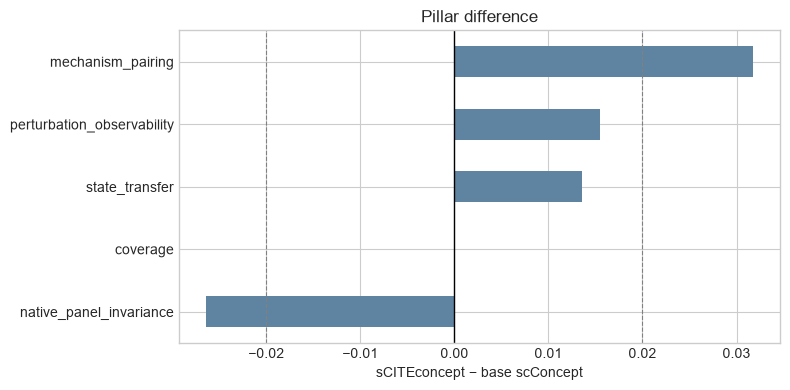

In [15]:
ax = p.difference.sort_values().plot.barh(figsize=(8, 4), color="#5f84a2")
ax.axvline(0, color="black", linewidth=1)
ax.axvline(0.02, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(-0.02, color="gray", linestyle="--", linewidth=0.8)
ax.set(title="Pillar difference", xlabel="sCITEconcept − base scConcept", ylabel="")
plt.tight_layout()


In [16]:
reconstructed = []
for model in MODELS:
    for pillar in PILLAR_WEIGHTS:
        components = metric_view(pillar)
        value = float((components[model] * components.metric_weight).sum())
        recorded = float(p.loc[pillar, model])
        reconstructed.append((model, pillar, value, recorded, value - recorded))
pd.DataFrame(reconstructed, columns=["model", "pillar", "from_components", "recorded", "difference"])


,model,pillar,from_components,recorded,difference
0,sCITEconcept,state_transfer,0.495447,0.495447,0.000000e+00
1,sCITEconcept,mechanism_pairing,0.786972,0.786972,0.000000e+00
2,sCITEconcept,perturbation_observability,0.876860,0.876860,0.000000e+00
3,sCITEconcept,native_panel_invariance,0.303795,0.303795,5.551115e-17
4,sCITEconcept,coverage,1.000000,1.000000,0.000000e+00
5,base_scConcept,state_transfer,0.481877,0.481877,5.551115e-17
6,base_scConcept,mechanism_pairing,0.755254,0.755254,-1.110223e-16
7,base_scConcept,perturbation_observability,0.861387,0.861387,0.000000e+00
8,base_scConcept,native_panel_invariance,0.330186,0.330186,5.551115e-17
9,base_scConcept,coverage,1.000000,1.000000,0.000000e+00


## 5. Broader biological benchmark suite

This suite inventories all completed direct comparisons with base scConcept.
Only rows marked `primary=True` count toward the headline. The result is 49 wins
and 11 losses across 60 primary scores.

Unlike the frozen-embedding composite, this is a count of heterogeneous tests,
not a calibrated scalar score. Each subsection defines the unit and then shows
every shipped metric, its direction, both model values, and the signed
directional difference.


In [17]:
scorecard = pd.read_csv(DATA / "overall_scorecard_rows.csv")
scorecard["primary"] = scorecard.primary.astype(str).str.lower().eq("true")

SCORE_DEFINITIONS = {
    "protein_cosine_at50": "Mean measured-protein cosine similarity among each cell's 50 nearest embedding neighbors.",
    "cross_platform_protein_cosine_at50": "The same protein-neighborhood cosine, restricted to neighbors measured on another technology.",
    "protein_high_lift_at50": "Enrichment over prevalence of protein-high cells among the 50 nearest neighbors.",
    "protein_ridge_mean_r2": "Mean protein-wise R² from a ridge-regression readout trained on embeddings.",
    "protein_ridge_median_r2": "Median protein-wise R² from the same ridge-regression readout.",
    "same_sample_at50": "Fraction of the 50 nearest neighbors drawn from the query cell's sample; diagnostic only.",
    "different_platform_at50": "Fraction of the 50 nearest neighbors measured on another technology; diagnostic only.",
    "protein_mask_jaccard_at50": "Mean Jaccard overlap of binarized protein-high states among the 50 nearest neighbors; diagnostic only.",
    "ct_random_macro_f1": "Macro F1 for cell-type prediction under a random cell split.",
    "ct_leave_platform_macro_f1": "Macro F1 for cell type when the test technology is absent from training.",
    "ct_leave_dataset_macro_f1": "Macro F1 for cell type when the test dataset is absent from training.",
    "label_random_macro_f1": "Macro F1 for label projection under a random cell split.",
    "leave_platform_macro_f1": "Macro F1 for label projection with the test technology held out.",
    "leave_dataset_macro_f1": "Macro F1 for label projection with the test dataset held out.",
    "same_cell_type_at50": "Fraction of the 50 nearest neighbors with the query cell's cell type.",
    "same_cell_type_tissue_at50": "Fraction of the 50 nearest neighbors matching both cell type and tissue.",
    "cross_platform_top1_same_ct_tissue": "Fraction whose closest eligible cell on another technology matches cell type and tissue.",
    "any_cross_platform_same_ct_tissue_at192": "Fraction with at least one cell-type-and-tissue match on another technology among 192 neighbors.",
    "any_cross_platform_same_ct_tissue_at_k": "Fraction with at least one cell-type-and-tissue match on another technology among the evaluated neighbors.",
    "surface_marker_lift_all_at50": "Mean enrichment over prevalence of marker-high cells among 50 neighbors.",
    "surface_marker_r2_all": "Mean R² for linear prediction of surface-marker scores from embeddings.",
    "same_tissue_diff_dataset_same_ct_at50": "Fraction of 50 neighbors from the same tissue, another dataset, and the same cell type.",
    "platform_random_macro_f1_lower_is_better": "Macro F1 for predicting technology under a random split; lower means less technology information.",
    "ari": "Adjusted Rand index between embedding-derived clusters and cell-type labels.",
    "nmi": "Normalized mutual information between embedding-derived clusters and cell-type labels.",
    "cell_type_asw_score": "Cell-type average-silhouette score, scaled so higher means better separation.",
    "graph_connectivity": "Average preservation of connected cell-type subgraphs in the neighbor graph.",
    "platform_ilisi_scaled": "Local inverse Simpson mixing score for technology, scaled to [0,1].",
    "platform_kbet_acceptance": "Fraction of neighborhoods accepted by the technology-mixing kBET test.",
    "dataset_ilisi_scaled": "Local inverse Simpson mixing score for dataset, scaled to [0,1].",
    "benchmark_macro_auroc": "AUROC averaged equally across Hallmark gene sets.",
    "benchmark_macro_auprc": "Area under the precision-recall curve averaged equally across Hallmark gene sets.",
    "benchmark_micro_auprc": "Area under one precision-recall curve formed from all gene-set decisions.",
    "benchmark_macro_f1": "Thresholded F1 averaged equally across Hallmark gene sets.",
    "benchmark_bce": "Mean binary cross-entropy for Hallmark membership; lower is better.",
    "top50_lift_macro": "Enrichment over prevalence of Hallmark members among each set's 50 highest-ranked genes.",
    "knn10_lift_macro": "Enrichment of same-Hallmark genes among each member gene's 10 nearest token neighbors.",
    "knn50_lift_macro": "Enrichment of same-Hallmark genes among each member gene's 50 nearest token neighbors.",
    "auroc_mean": "Mean area under the receiver-operating-characteristic curve across evaluation splits.",
    "auprc_mean": "Mean area under the precision-recall curve across evaluation splits.",
    "f1_mean": "Mean thresholded F1 across evaluation splits.",
    "balanced_accuracy_mean": "Mean of class-balanced accuracy across evaluation splits.",
    "mean_target_neighbor_lift_at50_delta": "Change from base scConcept in target-gene enrichment among 50 token neighbors.",
    "mean_target_neighbor_lift_at192_delta": "Change from base scConcept in target-gene enrichment among 192 token neighbors.",
    "mean_cross_platform_target_slot_fraction_at192_delta": "Change in the fraction of cross-technology neighbor slots occupied by relationship targets.",
    "mean_cross_platform_any_target_at192_delta": "Change in the fraction of queries retrieving any relationship target across technologies.",
    "mean_same_tissue_diff_dataset_target_slot_fraction_at192_delta": "Change in target-slot fraction when neighbors must share tissue and come from another dataset.",
    "mean_same_tissue_diff_dataset_any_target_at192_delta": "Change in any-target retrieval when neighbors must share tissue and come from another dataset.",
    "mean_high_neighbor_lift_at50_delta": "Change from base scConcept in marker-high-cell enrichment among 50 neighbors.",
    "mean_marker_score_r2_delta": "Change from base scConcept in linear R² for inhibitory-program marker scores.",
    "mean_cross_platform_any_high_neighbor_at192_delta": "Change in retrieval of any marker-high cell across technologies within 192 neighbors.",
    "mean_cross_dataset_any_high_neighbor_at192_delta": "Change in retrieval of any marker-high cell across datasets within 192 neighbors.",
    "ADT_mapped_mean_lift_delta": "Mean change from base scConcept in neighbor lift for RNA genes with a measured protein counterpart.",
    "matched_random_mean_lift_delta": "Mean change for expression-matched RNA genes without using protein-target membership; specificity control.",
}

def scorecard_view(benchmark):
    out = scorecard.query("benchmark == @benchmark").copy()
    out["definition"] = out.metric.map(SCORE_DEFINITIONS)
    if out.definition.isna().any():
        raise KeyError(f"Missing score definition: {out.loc[out.definition.isna(), 'metric'].tolist()}")
    return out[[
        "metric", "primary", "direction", "sCITEconcept", "base_scConcept",
        "directional_delta", "result", "definition",
    ]].reset_index(drop=True)

pd.read_csv(DATA / "overall_scorecard_summary.csv")


,comparison,primary_metrics,wins,losses,ties,win_rate
0,sCITEconcept vs base scConcept,60,49,11,0,0.816667


### Held-out CITE-seq protein readout

**Unit:** held-out paired RNA/protein cells. Neighborhood cosine tests local
protein similarity; high-state lift tests enrichment for protein-high cells;
ridge R² tests linear recovery of measured proteins. Cross-technology scores
restrict neighbors to a different measurement platform.


In [18]:
scorecard_view('Held-out CITE-seq protein readout')


,metric,primary,direction,sCITEconcept,base_scConcept,directional_delta,result,definition
0,protein_cosine_at50,True,higher,0.295617,0.252366,0.043250,win,Mean measured-protein cosine similarity among each cell's 50 nearest embedding neighbors.
1,cross_platform_protein_cosine_at50,True,higher,0.008731,-0.002353,0.011085,win,"The same protein-neighborhood cosine, restricted to neighbors measured on another technology."
2,protein_high_lift_at50,True,higher,5.411240,4.719177,0.692063,win,Enrichment over prevalence of protein-high cells among the 50 nearest neighbors.
3,protein_ridge_mean_r2,True,higher,0.248874,0.166090,0.082784,win,Mean protein-wise R² from a ridge-regression readout trained on embeddings.
4,protein_ridge_median_r2,True,higher,0.226971,0.152331,0.074641,win,Median protein-wise R² from the same ridge-regression readout.
5,same_sample_at50,False,higher,0.497327,0.423232,0.074096,win,Fraction of the 50 nearest neighbors drawn from the query cell's sample; diagnostic only.
6,different_platform_at50,False,higher,0.011337,0.003000,0.008338,win,Fraction of the 50 nearest neighbors measured on another technology; diagnostic only.
7,protein_mask_jaccard_at50,False,higher,0.757920,0.766788,-0.008868,loss,Mean Jaccard overlap of binarized protein-high states among the 50 nearest neighbors; diagnostic...


### Held-out cohort A cell and marker probes

**Unit:** cells from one held-out evaluation cohort. Scores cover cell-type
classification, leave-technology transfer, cell-type-plus-tissue neighborhoods,
marker-high enrichment, and marker-neighborhood similarity. Random-split scores
are leakage diagnostics; leave-group scores carry the transfer claim.


In [19]:
scorecard_view('Held-out cohort A cell and marker probes')


,metric,primary,direction,sCITEconcept,base_scConcept,directional_delta,result,definition
0,ct_random_macro_f1,True,higher,0.602498,0.586221,0.016277,win,Macro F1 for cell-type prediction under a random cell split.
1,ct_leave_platform_macro_f1,True,higher,0.431228,0.420234,0.010994,win,Macro F1 for cell type when the test technology is absent from training.
2,ct_leave_dataset_macro_f1,True,higher,0.491155,0.469097,0.022058,win,Macro F1 for cell type when the test dataset is absent from training.
3,same_cell_type_at50,True,higher,0.450602,0.416878,0.033724,win,Fraction of the 50 nearest neighbors with the query cell's cell type.
4,same_cell_type_tissue_at50,True,higher,0.310653,0.283377,0.027276,win,Fraction of the 50 nearest neighbors matching both cell type and tissue.
5,cross_platform_top1_same_ct_tissue,True,higher,0.082511,0.075430,0.007080,win,Fraction whose closest eligible cell on another technology matches cell type and tissue.
6,any_cross_platform_same_ct_tissue_at192,True,higher,0.328212,0.340017,-0.011806,loss,Fraction with at least one cell-type-and-tissue match on another technology among 192 neighbors.
7,surface_marker_lift_all_at50,True,higher,2.590460,2.510170,0.080290,win,Mean enrichment over prevalence of marker-high cells among 50 neighbors.
8,surface_marker_r2_all,True,higher,0.539242,0.495243,0.043998,win,Mean R² for linear prediction of surface-marker scores from embeddings.
9,same_tissue_diff_dataset_same_ct_at50,True,higher,0.355551,0.318184,0.037367,win,"Fraction of 50 neighbors from the same tissue, another dataset, and the same cell type."


### Held-out cohort A transfer, integration, and retrieval

**Unit:** cells in the same cohort under a broader integration protocol. Metrics
measure random-split and leave-group label projection, mixing across datasets or
technologies, same-label neighbor retrieval, and class separation.


In [20]:
scorecard_view('Held-out cohort A transfer, integration, and retrieval')


,metric,primary,direction,sCITEconcept,base_scConcept,directional_delta,result,definition
0,label_random_macro_f1,True,higher,0.593865,0.573608,0.020257,win,Macro F1 for label projection under a random cell split.
1,leave_platform_macro_f1,True,higher,0.484557,0.463963,0.020594,win,Macro F1 for label projection with the test technology held out.
2,leave_dataset_macro_f1,True,higher,0.530206,0.509664,0.020542,win,Macro F1 for label projection with the test dataset held out.
3,ari,True,higher,0.126992,0.072508,0.054484,win,Adjusted Rand index between embedding-derived clusters and cell-type labels.
4,nmi,True,higher,0.202584,0.134456,0.068128,win,Normalized mutual information between embedding-derived clusters and cell-type labels.
5,cell_type_asw_score,True,higher,0.490785,0.490435,0.000350,win,"Cell-type average-silhouette score, scaled so higher means better separation."
6,graph_connectivity,True,higher,0.990850,0.997153,-0.006303,loss,Average preservation of connected cell-type subgraphs in the neighbor graph.
7,platform_ilisi_scaled,False,higher,0.144760,0.136727,0.008034,win,"Local inverse Simpson mixing score for technology, scaled to [0,1]."
8,platform_kbet_acceptance,False,higher,0.023485,0.018808,0.004677,win,Fraction of neighborhoods accepted by the technology-mixing kBET test.
9,dataset_ilisi_scaled,False,higher,0.080518,0.080876,-0.000358,loss,"Local inverse Simpson mixing score for dataset, scaled to [0,1]."


### Held-out cohort B transfer, integration, and retrieval

**Unit:** an independent held-out cohort scored with the same protocol. This
checks whether the first cohort's pattern repeats in another sample.


In [21]:
scorecard_view('Held-out cohort B transfer, integration, and retrieval')


,metric,primary,direction,sCITEconcept,base_scConcept,directional_delta,result,definition
0,label_random_macro_f1,True,higher,0.586494,0.580750,0.005744,win,Macro F1 for label projection under a random cell split.
1,leave_platform_macro_f1,True,higher,0.481679,0.456687,0.024992,win,Macro F1 for label projection with the test technology held out.
2,leave_dataset_macro_f1,True,higher,0.508834,0.492207,0.016627,win,Macro F1 for label projection with the test dataset held out.
3,ari,True,higher,0.128319,0.064326,0.063994,win,Adjusted Rand index between embedding-derived clusters and cell-type labels.
4,nmi,True,higher,0.191530,0.109113,0.082417,win,Normalized mutual information between embedding-derived clusters and cell-type labels.
5,cell_type_asw_score,True,higher,0.493555,0.491932,0.001623,win,"Cell-type average-silhouette score, scaled so higher means better separation."
6,graph_connectivity,True,higher,0.991248,0.995944,-0.004696,loss,Average preservation of connected cell-type subgraphs in the neighbor graph.
7,platform_ilisi_scaled,False,higher,0.106245,0.110300,-0.004055,loss,"Local inverse Simpson mixing score for technology, scaled to [0,1]."
8,platform_kbet_acceptance,False,higher,0.018785,0.017789,0.000996,win,Fraction of neighborhoods accepted by the technology-mixing kBET test.
9,dataset_ilisi_scaled,False,higher,0.062709,0.065796,-0.003087,loss,"Local inverse Simpson mixing score for dataset, scaled to [0,1]."


### MSigDB Hallmark gene-token classification

**Unit:** static gene-token embeddings, not cell embeddings. Per-Hallmark gene
membership is predicted and summarized with AUROC, AUPRC, F1, binary
cross-entropy, and retrieval lift. These scores ask whether fine-tuning
preserved useful gene-vocabulary geometry.


In [22]:
scorecard_view('MSigDB Hallmark gene-token classification')


,metric,primary,direction,sCITEconcept,base_scConcept,directional_delta,result,definition
0,benchmark_macro_auroc,True,higher,0.750355,0.779444,-0.029088,loss,AUROC averaged equally across Hallmark gene sets.
1,benchmark_macro_auprc,True,higher,0.027059,0.030569,-0.003510,loss,Area under the precision-recall curve averaged equally across Hallmark gene sets.
2,benchmark_micro_auprc,True,higher,0.011230,0.008565,0.002665,win,Area under one precision-recall curve formed from all gene-set decisions.
3,benchmark_macro_f1,True,higher,0.066343,0.071181,-0.004839,loss,Thresholded F1 averaged equally across Hallmark gene sets.
4,benchmark_bce,True,lower,0.890728,1.171035,0.280307,win,Mean binary cross-entropy for Hallmark membership; lower is better.
5,top50_lift_macro,True,higher,12.653065,23.101983,-10.448918,loss,Enrichment over prevalence of Hallmark members among each set's 50 highest-ranked genes.
6,knn10_lift_macro,True,higher,36.131395,31.229886,4.901509,win,Enrichment of same-Hallmark genes among each member gene's 10 nearest token neighbors.
7,knn50_lift_macro,True,higher,19.698275,19.012084,0.686191,win,Enrichment of same-Hallmark genes among each member gene's 50 nearest token neighbors.


### DepMap broad-essentiality gene-token classification

**Unit:** static gene-token embeddings. Broad-essential genes are separated
from comparison genes and evaluated by mean AUROC, AUPRC, F1, and balanced
accuracy.


In [23]:
scorecard_view('DepMap broad-essentiality gene-token classification')


,metric,primary,direction,sCITEconcept,base_scConcept,directional_delta,result,definition
0,auroc_mean,True,higher,0.934411,0.934745,-0.000334,loss,Mean area under the receiver-operating-characteristic curve across evaluation splits.
1,auprc_mean,True,higher,0.614654,0.629954,-0.015300,loss,Mean area under the precision-recall curve across evaluation splits.
2,f1_mean,True,higher,0.290106,0.263787,0.026319,win,Mean thresholded F1 across evaluation splits.
3,balanced_accuracy_mean,True,higher,0.586534,0.576750,0.009784,win,Mean of class-balanced accuracy across evaluation splits.


### Tahoe-100M marginal-essentiality gene-token classification

**Unit:** static gene-token embeddings on an independently defined marginal-
essentiality task. The same four classification summaries are reported.


In [24]:
scorecard_view('Tahoe-100M marginal-essentiality gene-token classification')


,metric,primary,direction,sCITEconcept,base_scConcept,directional_delta,result,definition
0,auroc_mean,True,higher,0.947539,0.947362,0.000176,win,Mean area under the receiver-operating-characteristic curve across evaluation splits.
1,auprc_mean,True,higher,0.681341,0.689253,-0.007912,loss,Mean area under the precision-recall curve across evaluation splits.
2,f1_mean,True,higher,0.390928,0.325274,0.065654,win,Mean thresholded F1 across evaluation splits.
3,balanced_accuracy_mean,True,higher,0.624249,0.598079,0.026170,win,Mean of class-balanced accuracy across evaluation splits.


### Inhibitory relationship marker retrieval

**Unit:** genes in curated inhibitory ligand/receptor relationships. The scores
measure changes in target-neighbor retrieval after fine-tuning. For every score
ending in `_delta`, base scConcept is the zero reference and the sCITEconcept
value is the measured change. This is a representation diagnostic, not the
signed downstream cell-communication test reported later.


In [25]:
scorecard_view('Inhibitory relationship marker retrieval')


,metric,primary,direction,sCITEconcept,base_scConcept,directional_delta,result,definition
0,mean_target_neighbor_lift_at50_delta,True,higher,0.047043,0.0,0.047043,win,Change from base scConcept in target-gene enrichment among 50 token neighbors.
1,mean_target_neighbor_lift_at192_delta,True,higher,0.023653,0.0,0.023653,win,Change from base scConcept in target-gene enrichment among 192 token neighbors.
2,mean_cross_platform_target_slot_fraction_at192_delta,False,higher,0.007857,0.0,0.007857,win,Change in the fraction of cross-technology neighbor slots occupied by relationship targets.
3,mean_cross_platform_any_target_at192_delta,False,higher,-0.008776,0.0,-0.008776,loss,Change in the fraction of queries retrieving any relationship target across technologies.
4,mean_same_tissue_diff_dataset_target_slot_fraction_at192_delta,True,higher,0.003914,0.0,0.003914,win,Change in target-slot fraction when neighbors must share tissue and come from another dataset.
5,mean_same_tissue_diff_dataset_any_target_at192_delta,True,higher,0.025655,0.0,0.025655,win,Change in any-target retrieval when neighbors must share tissue and come from another dataset.


### Inhibitory program marker retrieval

**Unit:** genes in curated inhibitory programs. High-state lift asks whether
cells with strong program expression become easier to retrieve; neighborhood
readout measures whether their marker score is linearly recoverable. As above,
base scConcept is the zero reference for every `_delta` score.


In [26]:
scorecard_view('Inhibitory program marker retrieval')


,metric,primary,direction,sCITEconcept,base_scConcept,directional_delta,result,definition
0,mean_high_neighbor_lift_at50_delta,True,higher,0.045759,0.0,0.045759,win,Change from base scConcept in marker-high-cell enrichment among 50 neighbors.
1,mean_marker_score_r2_delta,True,higher,0.017967,0.0,0.017967,win,Change from base scConcept in linear R² for inhibitory-program marker scores.
2,mean_cross_platform_any_high_neighbor_at192_delta,False,higher,-0.016504,0.0,-0.016504,loss,Change in retrieval of any marker-high cell across technologies within 192 neighbors.
3,mean_cross_dataset_any_high_neighbor_at192_delta,False,higher,-0.010246,0.0,-0.010246,loss,Change in retrieval of any marker-high cell across datasets within 192 neighbors.


### ADT-mapped gene specificity

**Unit:** RNA genes corresponding to measured protein targets versus
expression-matched random genes. sCITEconcept improves the ADT-mapped genes
relative to base scConcept, but the matched random genes improve more. This
fails the narrow claim that representation change is specific to directly
measured proteins. Both rows are changes from base scConcept, which is therefore
shown as zero.


In [27]:
scorecard_view('ADT-mapped gene specificity')


,metric,primary,direction,sCITEconcept,base_scConcept,directional_delta,result,definition
0,ADT_mapped_mean_lift_delta,True,higher,0.961655,0.0,0.961655,win,Mean change from base scConcept in neighbor lift for RNA genes with a measured protein counterpart.
1,matched_random_mean_lift_delta,False,higher,1.698426,0.0,1.698426,win,Mean change for expression-matched RNA genes without using protein-target membership; specificit...


### Summary by benchmark family

Cell-level transfer and protein-aware readouts favor sCITEconcept most
consistently. Static gene-token classification is mixed.


In [28]:
pd.read_csv(DATA / 'overall_scorecard_family_summary.csv')


,family,primary_metrics,wins,losses,ties,win_rate,median_directional_delta,mean_directional_delta
0,Marker and program retrieval,6,6,0,0,1.000000,0.024654,0.027332
1,CITE-seq validation,5,5,0,0,1.000000,0.074641,0.180764
2,CITE-seq specificity,1,1,0,0,1.000000,0.961655,0.961655
3,Cell embedding,10,9,1,0,0.900000,0.024667,0.026726
4,Cell-label transfer and integration,22,19,3,0,0.863636,0.020399,0.023658
5,Gene essentiality,8,5,3,0,0.625000,0.004980,0.013070
6,Gene-token classification,8,4,4,0,0.500000,-0.000423,-0.576960


## 6. Independent spatial-platform benchmark

### Experimental design

The same formalin-fixed tissue-microarray cores were measured on serial sections
with Xenium, MERSCOPE, and CosMx. These are independent physical measurements,
not two software-derived views of one count vector.

- 6,242 prototypes from 205 source cores and 12 assay views.
- A prototype is the mean of 16 unit-normalized cell embeddings for one source
  core, assay view, and broad cell type.
- The mean embedding for each panel/technology context is removed before
  retrieval.
- Hard negatives are other cores matched on tissue microarray, tissue, tumor
  state, broad cell type, and target assay view.
- Uncertainty uses 500 paired bootstrap replicates over 155 eligible cores.

**Pairwise AUC** is the probability that the true same-core target is more
similar than a matched negative. **MRR** is mean reciprocal rank. **Recall@k**
is the fraction of queries whose true core appears among the first `k`
candidates.


In [29]:
tma = pd.read_csv(DATA / "independent_tma_retrieval.csv").set_index("model")
tma


,pairwise_auc,mrr,recall_at_1,recall_at_5
model,,,,
sCITEconcept,0.7905,0.5591,0.3597,0.8419
base_scConcept,0.7696,0.5324,0.3310,0.8189


In [30]:
margins = pd.read_csv(DATA / "independent_tma_winner_margins.csv")
margins


,metric,winner,runner_up,mean_delta,ci_low,ci_high,probability_delta_positive
0,pairwise_auc,sCITEconcept,base_scConcept,0.0208,0.0111,0.0326,1.0
1,reciprocal_rank,sCITEconcept,base_scConcept,0.0267,0.0145,0.0393,1.0
2,recall_at_1,sCITEconcept,base_scConcept,0.0287,0.0129,0.0442,1.0


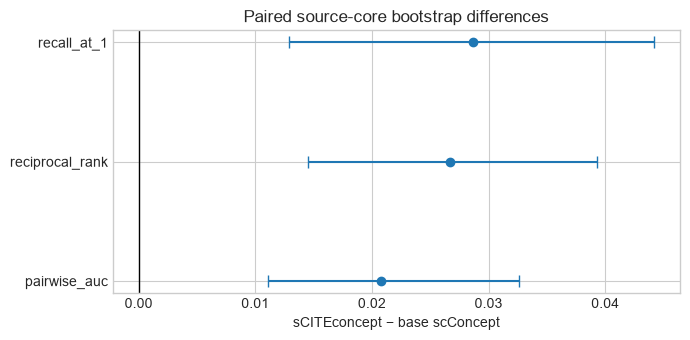

In [31]:
fig, ax = plt.subplots(figsize=(7, 3.5))
xerr = [margins.mean_delta - margins.ci_low, margins.ci_high - margins.mean_delta]
ax.errorbar(margins.mean_delta, margins.metric, xerr=xerr, fmt="o", capsize=4)
ax.axvline(0, color="black", linewidth=1)
ax.set(title="Paired source-core bootstrap differences", xlabel="sCITEconcept − base scConcept")
plt.tight_layout()


### Cross-platform label and patient-state transfer

Cell-type projection trains on one assay view and predicts broad cell type on
another; macro F1 and balanced accuracy weight classes equally. Tumor and PD-L1
state use leave-patient-out prediction and report balanced accuracy.


In [32]:
pd.read_csv(DATA / 'independent_tma_transfer.csv')


,task,metric,sCITEconcept,base_scConcept,delta
0,cell_type,macro_f1,0.5889,0.5630,0.0259
1,cell_type,balanced_accuracy,0.6324,0.6046,0.0278
2,tumor,balanced_accuracy,0.6719,0.6270,0.0449
3,pdl1,balanced_accuracy,0.5441,0.5148,0.0293


All three paired retrieval intervals exclude zero. This is the strongest
statistically supported advantage in the repository. Its interpretation is
still regional: a positive pair is the same tissue core across serial sections,
not the identical physical cell.


## 7. Cell-communication direction benchmark

### Checkpoint-family averages

The downstream model receives sender and receiver embeddings and predicts the
signed response to removing the sender's ligand. A context passes when the
receiver program changes in the expected direction.

`coexpression_pass_rate` and `inhibitory_pass_rate` are pass rates for the two
relationship classes. `balanced_pass_rate` gives the classes equal weight.
Values below average equally spaced checkpoints from each model's downstream
training trajectory.

This evaluates the complete downstream stack, not the encoder alone: the
spatial predictor and decoder are trained after embeddings are produced.


In [33]:
cellchat = pd.read_csv(DATA / "cellchat_family_summary.csv")
cellchat


,model,n_checkpoints,balanced_pass_rate,coexpression_pass_rate,inhibitory_pass_rate
0,sCITEconcept,20,0.5636,0.6427,0.4845
1,base_scConcept,20,0.5330,0.5875,0.4786


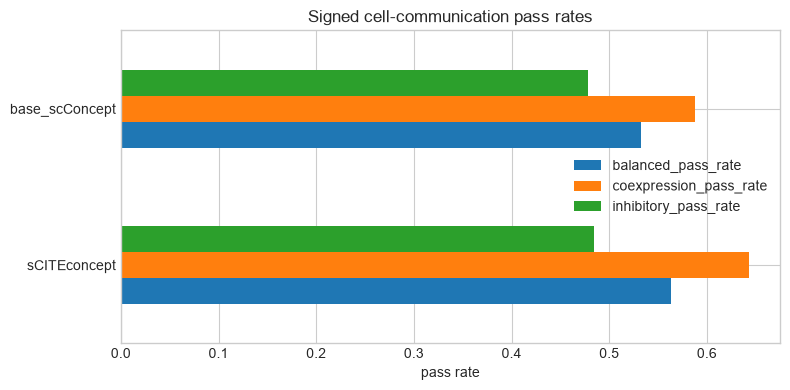

In [34]:
ax = cellchat.set_index("model")[["balanced_pass_rate", "coexpression_pass_rate", "inhibitory_pass_rate"]].plot.barh(figsize=(8, 4))
ax.set(title="Signed cell-communication pass rates", xlabel="pass rate", ylabel="")
plt.tight_layout()


### Paired-context uncertainty

A stricter analysis retains contexts with a defined direction and at least 40
supported sender/receiver pairs. It compares the exact same 90 contexts and uses
100,000 bootstrap draws plus a 100,000-draw paired sign-flip test.


In [35]:
pd.read_csv(DATA / 'cellchat_inhibitory_audit.csv')


,score,sciteconcept,base_scconcept,delta_points,ci_low_points,ci_high_points,p_value,n_contexts,interpretation
0,balanced_pass_rate,0.5660,0.5351,3.09,NaN,NaN,NaN,90,Overall stack-level family difference
1,inhibitory_pass_rate,0.4747,0.4693,0.54,-7.86,8.78,0.901,42,Statistical tie
2,coexpressive_pass_rate,0.6572,0.6008,5.64,0.67,10.56,NaN,48,Source of the balanced lift


The balanced improvement is driven by coexpressive relationships. Across 42
inhibitory contexts, the difference is +0.54 percentage points with a 95%
interval from −7.86 to +8.78 and `p=0.901`. That is a statistical tie. Large
wins for individual relationships are offset by similarly large regressions in
others.


## 8. Transformer-layer analysis

This benchmark asks which of the transformer's 16 layers exposes signaling
geometry most clearly. It uses 54,722 masked cell-role records across 95
contexts. Ligand, receptor, and expected response genes are removed. Every
layer sees identical records and probe splits.

The score is:

$$0.35\,\text{interaction AUPRC lift}
+0.25\,\text{tissue AUPRC lift}
+0.25\,\text{inhibitory macro-F1}
+0.15\,\text{coexpressive macro-F1}.$$

Differences below 0.005 are treated as ties. Layer 16 reproduces the default
released embedding and serves as a consistency check.


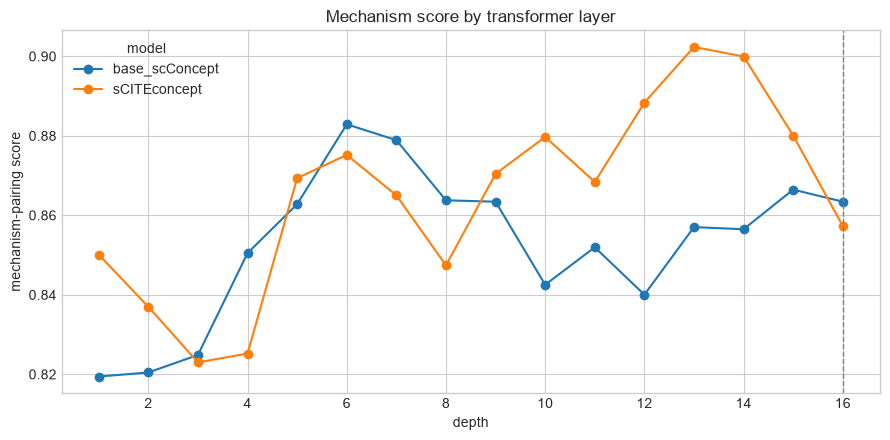

In [36]:
layers = pd.read_csv(DATA / "cellchat_layer_scores.csv")
layers.pivot(index="depth", columns="model", values="mechanism_pairing_score").plot(marker="o", figsize=(9, 4.5))
plt.axvline(16, color="gray", linestyle="--", linewidth=1)
plt.title("Mechanism score by transformer layer")
plt.ylabel("mechanism-pairing score")
plt.tight_layout()


In [37]:
pd.read_csv(DATA / 'cellchat_family_winners.csv')


,model,best_depth,best_score,final_layer_score,best_minus_final,heldout_interaction_pair_auprc_lift_scaled,heldout_tissue_pair_auprc_lift_scaled,inhibitory_pair_macro_f1,coexpressive_pair_macro_f1
0,sCITEconcept,13,0.902362,0.857286,0.045076,0.933158,0.793317,0.930994,0.964527
1,base_scConcept,6,0.882899,0.863435,0.019464,0.945994,0.721851,0.909692,0.959437


At the default final layer, base scConcept is slightly higher: 0.8634 versus
0.8573. With task-specific layer selection, sCITEconcept layer 13 reaches
0.9024, while base scConcept peaks at layer 6 with 0.8829. Layers 13 and 14 are
tied under the 0.005 tolerance.

This is selection on the same benchmark being reported. Layer 13 is therefore
a candidate readout for this task, not a universally superior replacement for
the final layer.


## 9. Recommendations and limitations

| Use case | Recommended starting point | Evidence |
| --- | --- | --- |
| Cross-dataset or cross-technology cell embeddings | sCITEconcept | Higher transfer scores and independent spatial-platform retrieval |
| Protein-aware cell neighborhoods | sCITEconcept | Better held-out CITE-seq neighborhood and linear-readout metrics |
| Matching the same cell across wide and narrow gene panels | base scConcept | Higher reciprocal rank and recall across panels |
| Static gene-token classification | Evaluate both | Results are mixed and task dependent |
| Cell-communication mechanism features | sCITEconcept layer 13 or 14 as a candidate | Stronger task-specific layer score; requires independent validation |
| Broad inhibitory direction prediction | Neither model is established as better | Paired inhibitory comparison is a statistical tie |

Limitations to retain with any summary:

- The released model used about 6% of eligible paired cells.
- The frozen-embedding composite lacks its prespecified grouped bootstrap.
- Some perturbation components saturate because repeated encoding is deterministic.
- The broader 60-score suite is an inventory, not a calibrated composite.
- The independent spatial benchmark matches tissue regions, not identical cells.
- Downstream cell-communication comparisons include trained components beyond
  the frozen encoder.
- Layer selection was performed on the reported mechanism benchmark.


## 10. Reproduction

### Read and rerun this notebook

```bash
python -m venv .venv
source .venv/bin/activate
pip install jupyter pandas matplotlib
jupyter lab sCITEconcept.ipynb
```

### Prepare aligned arrays

Place raw count and protein arrays in one directory using the schema documented
at the top of `scripts/build_training_pack.py`, then run:

```bash
python scripts/build_training_pack.py \
  --input-dir prepared_arrays \
  --output-dir training_pack
```

Source-study parsing is not included because access formats and licenses vary.
The packer validates the exact arrays consumed by training.

### Train or resume

Install PyTorch, Hugging Face Hub, OmegaConf, and scConcept 0.2.5, then run:

```bash
python scripts/train_sciteconcept.py \
  --pack-dir training_pack \
  --output-dir outputs/segment_1 \
  --epochs 4
```

The released trajectory selected epochs 3, 6, 44, and finally 94. To reproduce
its optimizer restarts, begin each continuation from the preceding selected
checkpoint and request 4, 44, and 56 additional epochs respectively. The CLI
restores model weights but intentionally creates a fresh AdamW optimizer.

The model loader downloads the pinned base architecture and the released
checkpoint. If the checkpoint repository requires authentication, pass a Hugging
Face access token to `load_sciteconcept`.


### Data provenance

Every CSV and JSON file in `data/` is a result snapshot, compact training
record, or model description used by this notebook. Raw cell data and model
weights are not stored here. The executable checks below bind the narrative to
the published values.


In [38]:
summary = pd.read_csv(DATA / "overall_scorecard_summary.csv").iloc[0]
inhibitory = pd.read_csv(DATA / "cellchat_inhibitory_audit.csv").query("score == 'inhibitory_pass_rate'").iloc[0]
winners = pd.read_csv(DATA / "cellchat_family_winners.csv").set_index("model")
selected = pd.read_csv(DATA / "training_history.csv").sort_values("validation_loss").iloc[0]

assert int(selected.epoch) == 94
assert abs(selected.validation_loss - 2.7110813041528066) < 1e-12
assert len(metric_glossary) == 20
assert set(metric_rows.model) == set(MODELS)
assert metric_rows.metric.nunique() == 20
assert 0 < overall_delta < 0.02
assert int(summary.primary_metrics) == 60 and int(summary.wins) == 49
assert scorecard.benchmark.nunique() == 10
assert (margins.ci_low > 0).all()
assert inhibitory.ci_low_points < 0 < inhibitory.ci_high_points
assert inhibitory.p_value == 0.901
assert int(winners.loc["sCITEconcept", "best_depth"]) == 13
assert winners.loc["sCITEconcept", "best_score"] > winners.loc["base_scConcept", "best_score"]
assert winners.loc["sCITEconcept", "final_layer_score"] < winners.loc["base_scConcept", "final_layer_score"]
print("All published values and interpretation checks passed.")


All published values and interpretation checks passed.
